In [52]:
pip install pandas numpy scikit-learn nltk

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [53]:
pip install nltk

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [54]:
import pandas as pd

df = pd.read_csv("customer_support_tickets.csv")

df.head()

,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating
0,1,Marisa Obrien,carrollallison@example.com,32,Other,GoPro Hero,2021-03-22,Technical issue,Product setup,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Social media,2023-06-01 12:15:36,NaN,NaN
1,2,Jessica Rios,clarkeashley@example.com,42,Female,LG Smart TV,2021-05-22,Technical issue,Peripheral compatibility,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Chat,2023-06-01 16:45:38,NaN,NaN
2,3,Christopher Robbins,gonzalestracy@example.com,48,Other,Dell XPS,2020-07-14,Technical issue,Network problem,I'm facing a problem with my {product_purchase...,Closed,Case maybe show recently my computer follow.,Low,Social media,2023-06-01 11:14:38,2023-06-01 18:05:38,3.0
3,4,Christina Dillon,bradleyolson@example.org,27,Female,Microsoft Office,2020-11-13,Billing inquiry,Account access,I'm having an issue with the {product_purchase...,Closed,Try capital clearly never color toward story.,Low,Social media,2023-06-01 07:29:40,2023-06-01 01:57:40,3.0
4,5,Alexander Carroll,bradleymark@example.com,67,Female,Autodesk AutoCAD,2020-02-04,Billing inquiry,Data loss,I'm having an issue with the {product_purchase...,Closed,West decision evidence bit.,Low,Email,2023-06-01 00:12:42,2023-06-01 19:53:42,1.0


In [55]:
print("Information about given dataset")
df.info()

Information about given dataset
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8469 entries, 0 to 8468
Data columns (total 17 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Ticket ID                     8469 non-null   int64  
 1   Customer Name                 8469 non-null   object 
 2   Customer Email                8469 non-null   object 
 3   Customer Age                  8469 non-null   int64  
 4   Customer Gender               8469 non-null   object 
 5   Product Purchased             8469 non-null   object 
 6   Date of Purchase              8469 non-null   object 
 7   Ticket Type                   8469 non-null   object 
 8   Ticket Subject                8469 non-null   object 
 9   Ticket Description            8469 non-null   object 
 10  Ticket Status                 8469 non-null   object 
 11  Resolution                    2769 non-null   object 
 12  Ticket Priority               

In [56]:
print("Columns of the dataset")
print(df.columns)

Columns of the dataset
Index(['Ticket ID', 'Customer Name', 'Customer Email', 'Customer Age',
       'Customer Gender', 'Product Purchased', 'Date of Purchase',
       'Ticket Type', 'Ticket Subject', 'Ticket Description', 'Ticket Status',
       'Resolution', 'Ticket Priority', 'Ticket Channel',
       'First Response Time', 'Time to Resolution',
       'Customer Satisfaction Rating'],
      dtype='object')


In [57]:
print("Handle missing values",end=' ')
try:
    df.isnull().sum()
    df = df[['Ticket Description', 'Ticket Type']]
    df.columns = ['text', 'category']
    df.dropna(inplace=True)
    print("is completed")
except:
    print("is not completed")

Handle missing values is completed


In [58]:
import re
def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    return text
df['clean_text'] = df['text'].apply(clean_text)
print("After converting the text")
df[['text', 'clean_text']].head()

After converting the text


,text,clean_text
0,I'm having an issue with the {product_purchase...,im having an issue with the productpurchased p...
1,I'm having an issue with the {product_purchase...,im having an issue with the productpurchased p...
2,I'm facing a problem with my {product_purchase...,im facing a problem with my productpurchased t...
3,I'm having an issue with the {product_purchase...,im having an issue with the productpurchased p...
4,I'm having an issue with the {product_purchase...,im having an issue with the productpurchased p...


In [59]:
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))
def remove_stopwords(text):
    words = text.split()
    filtered_words = [word for word in words if word not in stop_words]
    return " ".join(filtered_words)
df['clean_text'] = df['clean_text'].apply(remove_stopwords)
df[['text', 'clean_text']].head()
words="payment failed".split()
l=[word for word in words if word not in stop_words]

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\sruja\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [60]:
#train_test_split()
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
vectorizer = TfidfVectorizer()
x = vectorizer.fit_transform(df['clean_text'])
y = df['category']
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=42)


In [61]:
from sklearn.naive_bayes import MultinomialNB
model = MultinomialNB()
model.fit(x_train, y_train)
y_pred = model.predict(x_test)

In [62]:
from sklearn.metrics import accuracy_score, classification_report
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)
print(classification_report(y_test, y_pred))

Accuracy: 0.18890200708382526
                      precision    recall  f1-score   support

     Billing inquiry       0.15      0.04      0.07       357
Cancellation request       0.18      0.15      0.17       327
     Product inquiry       0.14      0.11      0.13       316
      Refund request       0.20      0.31      0.24       345
     Technical issue       0.22      0.32      0.26       349

            accuracy                           0.19      1694
           macro avg       0.18      0.19      0.17      1694
        weighted avg       0.18      0.19      0.17      1694



In [63]:
sample_ticket = ["payment failed and money deducted"]
sample_vector = vectorizer.transform(sample_ticket)
prediction = model.predict(sample_vector)
print("Predicted Category:", prediction[0])

Predicted Category: Product inquiry


In [64]:
def priority_tag(text):
    text = text.lower()
    if "failed" in text or "urgent" in text or "error" in text:
        return "High"
    elif "issue" in text or "delay" in text:
        return "Medium"
    else:
        return "Low"

df['priority'] = df['text'].apply(priority_tag)
df[['text', 'priority']].head()

,text,priority
0,I'm having an issue with the {product_purchase...,Medium
1,I'm having an issue with the {product_purchase...,Medium
2,I'm facing a problem with my {product_purchase...,Low
3,I'm having an issue with the {product_purchase...,Medium
4,I'm having an issue with the {product_purchase...,Medium


In [65]:
sample_ticket = ["payment failed and money deducted urgently"]
# clean ticket
cleaned = clean_text(sample_ticket[0])
# remove stopwords
cleaned = remove_stopwords(cleaned)
# convert to vector
vector = vectorizer.transform([cleaned])
# predict category
category = model.predict(vector)[0]
# predict priority
priority = priority_tag(sample_ticket[0])
print("Predicted Category:", category)
print("Predicted Priority:", priority)

Predicted Category: Product inquiry
Predicted Priority: High


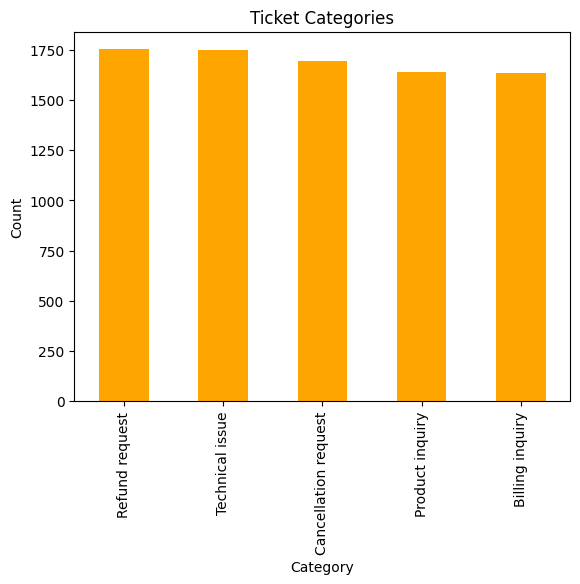

In [66]:
import matplotlib.pyplot as plt
df['category'].value_counts().plot(kind='bar',color='orange')
plt.title("Ticket Categories")
plt.xlabel("Category")
plt.ylabel("Count")
plt.show()